# Expansion — spectral reconstruction beyond scalar autocorrelation (standalone)

자립형 노트북. 본 노트북만으로 Expansion 1~4가 실행된다 (메인 노트북 의존 없음).

$A(t)=\langle\psi_0|U(t)|\psi_0\rangle=\sum_n|\langle E_n|\psi_0\rangle|^2 e^{-iE_n t}$ 는 초기상태와 overlap이 있는 eigenstate만 보여주는 overlap-weighted spectrum이다. 확장은 **Coverage**(E1) · **Resolution**(E2) · **Validation**(E3) · **Robustness**(E4) 네 축.

모델: $N=6$ periodic anisotropic Heisenberg + transverse-$X$, $J_x{=}1,J_y{=}0.7,J_z{=}1.2,h_x{=}0.4$, $|\psi_0\rangle=|010101\rangle$ (qubit-0-first).

In [1]:
# ===== Foundation: imports + model context (self-contained) =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq
from scipy.signal import find_peaks
from pathlib import Path
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
Path("tables").mkdir(exist_ok=True); Path("figures").mkdir(exist_ok=True)

# ---- model (identical to the main notebook) ----
N = 6
Jx, Jy, Jz, hx = 1.0, 0.7, 1.2, 0.4
BITSTRING_Q0_FIRST = "010101"
BITSTRING_QISKIT   = BITSTRING_Q0_FIRST[::-1]      # "101010" (qubit-0-last, Qiskit label)
DT_GRID, T_MAX = 0.05, 15.0
TIMES = np.arange(0.0, T_MAX + 0.5*DT_GRID, DT_GRID)
K_VALUES = [1, 2, 3]

def ring_bonds(n):
    allb = [(j, (j + 1) % n) for j in range(n)]
    return allb, allb[0::2], allb[1::2]

def build_heisenberg_hamiltonian(num_qubits=N, ordering="grouped"):
    allb, even, odd = ring_bonds(num_qubits); rows = []
    inter = [("XX", Jx), ("YY", Jy), ("ZZ", Jz)]
    if ordering == "grouped":
        for _nm, L in [("even", even), ("odd", odd)]:
            for P, c in inter:
                for (a, b) in L: rows.append((P, [a, b], c))
    else:
        for (a, b) in allb:
            for P, c in inter: rows.append((P, [a, b], c))
    if hx != 0.0:
        for j in range(num_qubits): rows.append(("X", [j], hx))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=num_qubits)

H_spo = build_heisenberg_hamiltonian(ordering="grouped")
eigvals, eigvecs = np.linalg.eigh(H_spo.to_matrix())
psi0 = Statevector.from_label(BITSTRING_QISKIT)
_c0  = eigvecs.conj().T @ psi0.data

def exact_state(t):
    return Statevector(eigvecs @ (np.exp(-1j*float(t)*eigvals) * _c0))

A_exact = np.array([psi0.data.conj() @ exact_state(t).data for t in TIMES])

SETTINGS = {}
for k in K_VALUES:
    SETTINGS["LT_k%d" % k]  = LieTrotter(reps=k)
    SETTINGS["ST2_k%d" % k] = SuzukiTrotter(order=2, reps=k)
    SETTINGS["ST4_k%d" % k] = SuzukiTrotter(order=4, reps=k)

def state_prep(qc):
    for i, ch in enumerate(reversed(BITSTRING_QISKIT)):
        if ch == "1": qc.x(i)
    return qc

def product_formula_state(t, synthesis, ordering="grouped"):
    qc = QuantumCircuit(N); state_prep(qc)
    qc.append(PauliEvolutionGate(build_heisenberg_hamiltonian(ordering=ordering),
                                 time=float(t), synthesis=synthesis), range(N))
    return Statevector.from_instruction(qc.decompose())

assert abs(A_exact[0].real - 1.0) < 1e-9, "A(0) should be 1"
print("Foundation ready: N=%d | %d eigenvalues | %d time points | A(0)=%.4f"
      % (N, len(eigvals), len(TIMES), A_exact[0].real))
print("settings:", list(SETTINGS))


Foundation ready: N=6 | 64 eigenvalues | 301 time points | A(0)=1.0000
settings: ['LT_k1', 'ST2_k1', 'ST4_k1', 'LT_k2', 'ST2_k2', 'ST4_k2', 'LT_k3', 'ST2_k3', 'ST4_k3']


## Expansion 1 — Multiple initial states broaden spectral coverage

$A_\alpha(t)=\sum_n|\langle E_n|\psi_\alpha\rangle|^2 e^{-iE_n t}$. 초기 product state를 바꾸면 overlap weight가 달라져 보이는 eigenenergy 집합이 바뀐다. 여러 상태의 visible set을 union → coverage 확대. ($J_x\neq J_y, h_x\neq0$이라 $S_z$ 비보존 → sector가 아니라 overlap 다양화.)

,initial_state,label,n_visible_eigvals,visible_overlap_weight,top_peak_matched
0,Neel,101010,9,0.981,True
1,anti-Neel,010101,9,0.981,True
2,single-excitation,000001,21,0.947,True
3,domain-wall,111000,19,0.967,True
4,random-A,100110,22,0.925,True
5,random-B,011001,22,0.925,True


Union of visible eigenvalues across 6 initial states: 36 of 64 total -> single A(t) is overlap-limited.


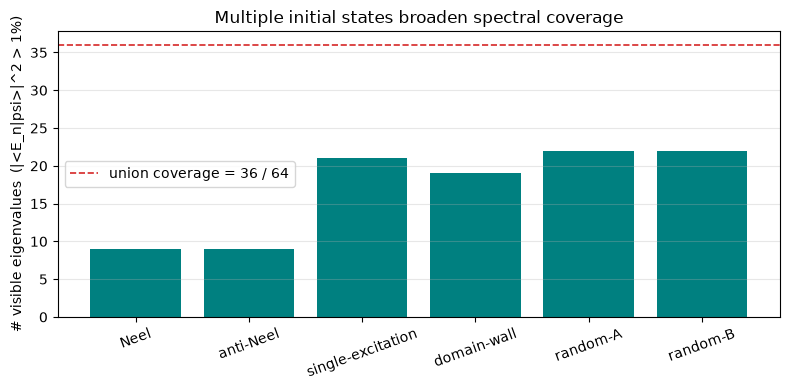

In [2]:
# ===== Expansion 1: multiple initial states broaden spectral coverage =====
from qiskit.quantum_info import Statevector as _SV
from scipy.signal import find_peaks as _find_peaks

def _autocorr_of(label):
    psi = _SV.from_label(label).data
    c = eigvecs.conj().T @ psi
    wts = np.abs(c) ** 2
    A = np.exp(-1j * np.outer(TIMES, eigvals)) @ wts
    return A, wts

_init_states = {
    "Neel": BITSTRING_QISKIT,
    "anti-Neel": "".join("1" if ch == "0" else "0" for ch in BITSTRING_QISKIT),
    "single-excitation": "0" * (N - 1) + "1",
    "domain-wall": "1" * (N // 2) + "0" * (N - N // 2),
    "random-A": "100110"[:N],
    "random-B": "011001"[:N],
}
_VIS_THR = 0.01
_dE2 = 2 * (2 * np.pi / T_MAX)
_exp_rows, _union = [], set()
for nm, lab in _init_states.items():
    A, wts = _autocorr_of(lab)
    vis = np.where(wts > _VIS_THR)[0]
    _union |= set(np.round(eigvals[vis], 3))
    win = np.hanning(len(A)); sp = fftshift(fft(A * win))
    en = -2 * np.pi * fftshift(fftfreq(len(A), d=DT_GRID)); o = np.argsort(en); en, mg = en[o], np.abs(sp)[o]
    pk, _ = _find_peaks(mg, height=mg.max() * 0.1)
    top_e = en[pk[np.argmax(mg[pk])]] if len(pk) else np.nan
    matched = bool(np.min(np.abs(eigvals - top_e)) <= _dE2) if np.isfinite(top_e) else False
    _exp_rows.append(dict(initial_state=nm, label=lab, n_visible_eigvals=int(len(vis)),
                          visible_overlap_weight=round(float(wts[vis].sum()), 3), top_peak_matched=matched))
expansion_sweep = pd.DataFrame(_exp_rows)
display(expansion_sweep)
expansion_sweep.to_csv("tables/expansion_initial_state_sweep.csv", index=False)
print("Union of visible eigenvalues across %d initial states: %d of %d total -> single A(t) is overlap-limited."
      % (len(_init_states), len(_union), len(eigvals)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(expansion_sweep.initial_state, expansion_sweep.n_visible_eigvals, color="teal")
ax.axhline(len(_union), color="tab:red", ls="--", lw=1.2, label="union coverage = %d / %d" % (len(_union), len(eigvals)))
ax.set_ylabel("# visible eigenvalues  (|<E_n|psi>|^2 > 1%)")
ax.set_title("Multiple initial states broaden spectral coverage")
ax.tick_params(axis="x", rotation=20); ax.legend(); ax.grid(alpha=.3, axis="y")
plt.tight_layout(); fig.savefig("figures/expansion_initial_state_sweep.png", dpi=160, bbox_inches="tight"); plt.show()


## Expansion 2 — FFT window / zero-padding / resolution ablation

관측 peak는 finite-time windowed DFT peak. 분해능 $\Delta E\approx 2\pi/T_{\max}$. window·zero-padding·$T_{\max}$ 절단을 바꿔 peak 개수·매칭오차를 점검한다.

,variant,T_eff,dE,n_peaks,mean_peak_match_err
0,"rectangular, T_max",15.05,0.417,7,0.0743
1,"Hanning, T_max",15.05,0.417,5,0.0799
2,Hanning + zero-pad x4,15.05,0.417,5,0.0454
3,"Hanning, T_max/2",7.50,0.838,4,0.1242
4,"Hanning, T_max/4",3.75,1.676,3,0.3119


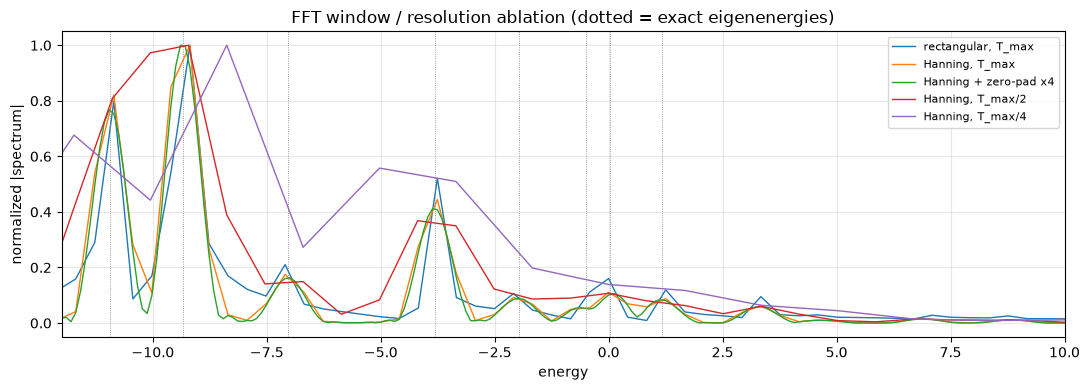

Shorter T_max -> larger dE=2pi/T_max -> fewer, less accurate peaks; zero-padding interpolates (sharper localization).


In [3]:
# ===== Expansion 2: FFT window / zero-padding / resolution ablation =====
def _spec(A_seg, dt, pad=1, window="hann"):
    n = len(A_seg); wv = np.hanning(n) if window == "hann" else np.ones(n)
    s = fftshift(fft(A_seg * wv, n=pad * n)); en = -2 * np.pi * fftshift(fftfreq(pad * n, d=dt))
    o = np.argsort(en); return en[o], np.abs(s)[o]

_variants = [
    ("rectangular, T_max",    A_exact,                   1, "rect"),
    ("Hanning, T_max",        A_exact,                   1, "hann"),
    ("Hanning + zero-pad x4", A_exact,                   4, "hann"),
    ("Hanning, T_max/2",      A_exact[:len(A_exact)//2], 1, "hann"),
    ("Hanning, T_max/4",      A_exact[:len(A_exact)//4], 1, "hann"),
]
_abl_rows = []
fig, ax = plt.subplots(figsize=(11, 4))
for nm, seg, pad, wd in _variants:
    en, mg = _spec(seg, DT_GRID, pad, wd)
    pk, _ = _find_peaks(mg, height=mg.max() * 0.1); pe = en[pk]
    T_eff = len(seg) * DT_GRID; dE_eff = 2 * np.pi / T_eff
    err = float(np.mean([np.min(np.abs(eigvals - p)) for p in pe])) if len(pe) else float("nan")
    _abl_rows.append(dict(variant=nm, T_eff=round(T_eff, 2), dE=round(dE_eff, 3),
                          n_peaks=int(len(pe)), mean_peak_match_err=round(err, 4)))
    ax.plot(en, mg / mg.max(), lw=1, label=nm)
ablation_table = pd.DataFrame(_abl_rows)
display(ablation_table); ablation_table.to_csv("tables/expansion_fft_ablation.csv", index=False)
for ev in eigvals[(np.abs(_c0) ** 2) > 0.02]:
    ax.axvline(ev, color="gray", ls=":", lw=0.6)
ax.set_xlim(-12, 10); ax.set_xlabel("energy"); ax.set_ylabel("normalized |spectrum|")
ax.set_title("FFT window / resolution ablation (dotted = exact eigenenergies)")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); fig.savefig("figures/expansion_fft_ablation.png", dpi=160, bbox_inches="tight"); plt.show()
print("Shorter T_max -> larger dE=2pi/T_max -> fewer, less accurate peaks; zero-padding interpolates (sharper localization).")


## Expansion 3 — DFT peak ↔ exact eigenvalue matching (enriched)

exact diagonalization spectrum과 peak를 $1\Delta E$/$2\Delta E$ 허용오차로 매칭하고 top-$k$ overlap coverage를 보고 → peak가 실제 eigenenergy임을 검증.

In [4]:
# ===== Expansion 3: DFT peak <-> exact eigenvalue matching (enriched) =====
_w = np.abs(_c0) ** 2
_win = np.hanning(len(A_exact)); _sp = fftshift(fft(A_exact * _win))
_en = -2 * np.pi * fftshift(fftfreq(len(A_exact), d=DT_GRID)); _o = np.argsort(_en); _en, _mg = _en[_o], np.abs(_sp)[_o]
_dE = 2 * np.pi / T_MAX
_pk, _ = _find_peaks(_mg, height=_mg.max() * 0.1); _top = _pk[np.argsort(_mg[_pk])[::-1][:8]]; _pe = np.sort(_en[_top])
_near = np.array([eigvals[np.argmin(np.abs(eigvals - p))] for p in _pe])
expansion_peak_match = pd.DataFrame(dict(
    peak_energy=np.round(_pe, 3), nearest_eigenvalue=np.round(_near, 3),
    abs_diff=np.round(np.abs(_pe - _near), 3),
    within_1dE=np.abs(_pe - _near) <= _dE, within_2dE=np.abs(_pe - _near) <= 2 * _dE,
    overlap_weight=[round(float(_w[np.argmin(np.abs(eigvals - p))]), 3) for p in _pe]))
display(expansion_peak_match); expansion_peak_match.to_csv("tables/expansion_peak_match.csv", index=False)
_topk_cov = float(np.sort(_w)[::-1][:len(_pe)].sum())
print("dE = 2pi/T_max = %.3f | within 1dE: %d/%d | within 2dE: %d/%d | top-%d overlap coverage: %.3f"
      % (_dE, int(expansion_peak_match.within_1dE.sum()), len(_pe),
         int(expansion_peak_match.within_2dE.sum()), len(_pe), len(_pe), _topk_cov))


,peak_energy,nearest_eigenvalue,abs_diff,within_1dE,within_2dE,overlap_weight
0,-10.855,-10.937,0.083,True,True,0.274
1,-9.185,-9.341,0.156,True,True,0.359
2,-7.097,-7.031,0.066,True,True,0.058
3,-3.757,-3.819,0.062,True,True,0.148
4,-0.000,0.033,0.033,True,True,0.041


dE = 2pi/T_max = 0.419 | within 1dE: 5/5 | within 2dE: 5/5 | top-5 overlap coverage: 0.880


## Expansion 4 — Trotterized autocorrelation spectrum stability

$A_{PF}(t)$를 FFT해 exact spectrum과 비교. 각 지배 exact peak → 최근접 PF peak 거리(위치 보존)와 진폭 왜곡을 본다.

,setting,n_exact_dominant_peaks,n_pf_peaks,mean_nearest_peak_pos_shift
0,ST2_k2,3,7,0.139
1,ST2_k3,3,9,0.417


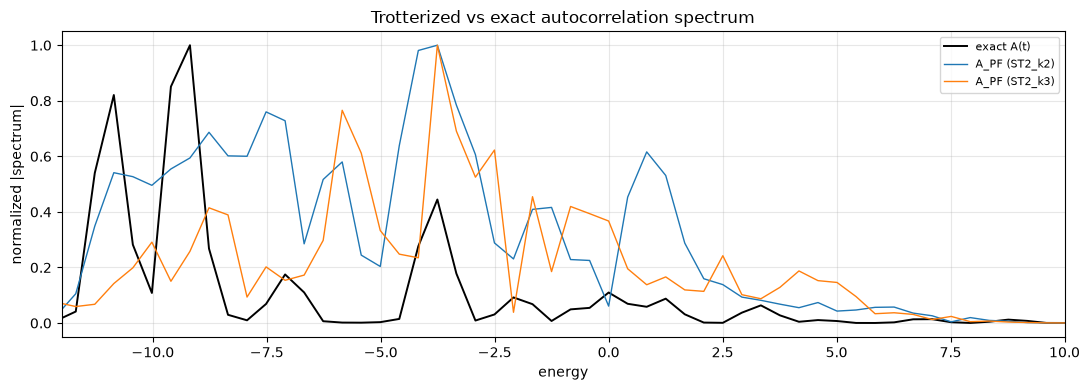

Dominant eigenenergy peaks are preserved up to FFT resolution (~1-2 dE); amplitudes (and which peak is tallest) distort with Trotter error.


In [5]:
# ===== Expansion 4: Trotterized autocorrelation spectrum stability =====
def _spectrum_of(A_series):
    win = np.hanning(len(A_series)); s = fftshift(fft(A_series * win))
    en = -2 * np.pi * fftshift(fftfreq(len(A_series), d=DT_GRID)); o = np.argsort(en); return en[o], np.abs(s)[o]

en_x, mg_x = _spectrum_of(A_exact)
fig, ax = plt.subplots(figsize=(11, 4)); ax.plot(en_x, mg_x / mg_x.max(), "k-", lw=1.4, label="exact A(t)")
_spec_rows = []
for nm in ["ST2_k2", "ST2_k3"]:
    syn = SETTINGS[nm]
    A_pf = np.array([complex(psi0.data.conj() @ product_formula_state(t, syn).data) for t in TIMES])
    en_p, mg_p = _spectrum_of(A_pf)
    ax.plot(en_p, mg_p / mg_p.max(), lw=1, label="A_PF (%s)" % nm)
    pkx, _ = _find_peaks(mg_x, height=mg_x.max() * 0.2); pkp, _ = _find_peaks(mg_p, height=mg_p.max() * 0.2)
    ex_pos = en_x[pkx]; pf_pos = en_p[pkp]
    pos_shift = float(np.mean([np.min(np.abs(pf_pos - e)) for e in ex_pos])) if len(pf_pos) else float("nan")
    _spec_rows.append(dict(setting=nm, n_exact_dominant_peaks=int(len(ex_pos)), n_pf_peaks=int(len(pf_pos)),
                           mean_nearest_peak_pos_shift=round(pos_shift, 3)))
expansion_trotter_spectrum = pd.DataFrame(_spec_rows)
display(expansion_trotter_spectrum); expansion_trotter_spectrum.to_csv("tables/expansion_trotter_spectrum.csv", index=False)
ax.set_xlim(-12, 10); ax.set_xlabel("energy"); ax.set_ylabel("normalized |spectrum|")
ax.set_title("Trotterized vs exact autocorrelation spectrum")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); fig.savefig("figures/expansion_trotter_spectrum.png", dpi=160, bbox_inches="tight"); plt.show()
print("Dominant eigenenergy peaks are preserved up to FFT resolution (~1-2 dE); amplitudes (and which peak is tallest) distort with Trotter error.")
